# Array Configuration Generation
This notebook generates and visualizes various antenna array configurations for FASR using `fasr_solar_simul` (fss).

In [2]:
import fasr_solar_simul as fss
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c
import os

# Speed of light in m/s
C_LIGHT = c
import matplotlib
%matplotlib inline

## Set Site Information

In [3]:
# set reference longtitude and latitude
dsa_longitude = -114.425164
dsa_latitude = 39.54780
dsa_altitude = 1736.125

## 3-armed Log Spiral Configurations

Number of turns 1.497372046505208
Minimum baseline length: 17.9 m
Maximum baseline length: 4503.1 m
'generate_log_spiral_antenna_positions' completed at 2026-02-11 11:25:21; runtime: 0.00 seconds
fig saved to fig-fasr_Log_Spiral-72-n_arms=3-antennas_per_arm=24-k=0.43-r0=35.0-r_max=2000.jpg
Set 1: Beam (Natural) FWHM Major: 22.64 arcsec, Minor: 22.45"
Set 1: Beam (Uniform) FWHM Major: 4.72 arcsec, Minor: 4.57"
Set 1: Sidelobe RMS (Natural): 0.8%
Set 1: Sidelobe RMS (Uniform): 1.6%
'plot_all_panels' completed at 2026-02-11 11:25:23; runtime: 1.39 seconds


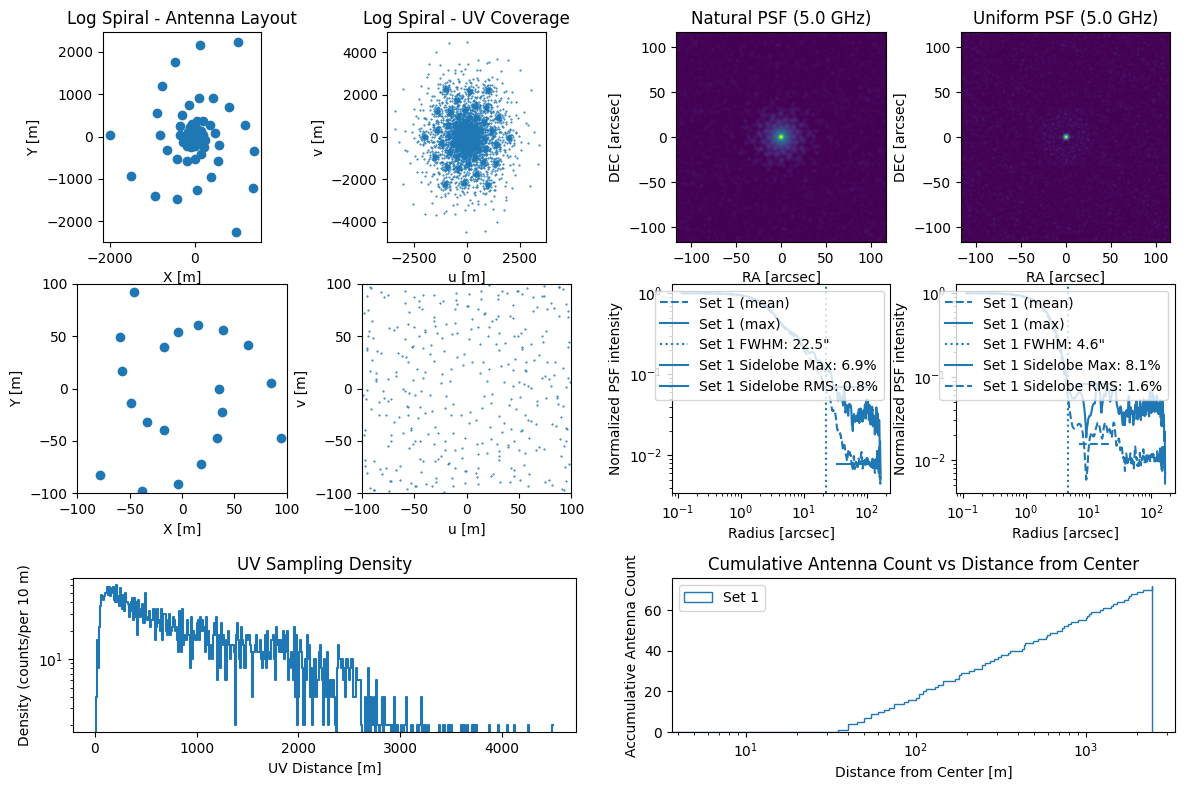

In [4]:
from importlib import reload
reload(fss)
# 72-element spiral with an optimized winding parameter k (corresponding to 1.5 turns), 
#     inner radius of 35 m, and outer radius of 2000 m

# Define log-spiral parameters
array_config = {"n_arms": 3, "antennas_per_arm": 24, "k": 0.43, "r0": 35, "r_max": 2000,
                "latitude": dsa_latitude, "clockwise":True}


positions_logspiral = fss.generate_log_spiral_antenna_positions(**array_config)

figname = (
    f"fig-fasr_Log_Spiral-{len(positions_logspiral)}-"
    f"n_arms={array_config['n_arms']}-antennas_per_arm={array_config['antennas_per_arm']}-"
    f"k={array_config['k']:.2f}-"
    f"r0={array_config['r0']:.1f}-r_max={array_config['r_max']:.0f}.jpg")
print(f'fig saved to {figname}')
figsubfolder = figname.rstrip('.jpg')
formatted_params = [
    rf"$n_{{\rm arms}}={array_config['n_arms']}$",
    rf"$\mbox{{antennas per arm}}={array_config['antennas_per_arm']}$",
    rf"$k={array_config['k']:.2f}$",
    rf"$r_0={array_config['r0']:.1f}\,\mbox{{m}}$",
    rf"$r_{{\rm max}}={array_config['r_max']:.0f}\,\mbox{{m}}$"
]

# Create a full string that also includes the spiral equation.
array_config_str = (
    rf"$n_{{arms}}={array_config['n_arms']}, "
    rf"n_{{perarm}}={array_config['antennas_per_arm']}, "
    rf"k={array_config['k']:.2f}, "
    rf"r_0={array_config['r0']:.1f}\,m, r_{{max}}={array_config['r_max']:.0f}\,m$"
)
fss.plot_all_panels(positions_logspiral, "Log Spiral", frequency=5, figname=figname, plot_psf_fit=False)
# fig = plt.gcf()
# ax = fig.axes[0]
# ax.set_xlim(-10,10)
# ax.set_ylim(-10,10)

## Generate a hybrid array with a 72-element spiral and a dense random core

Generating spiral with 3 arms, 24 antennas per arm
Total spiral antennas: 72
Adjusted core antennas to: 48
Generated 48 core antennas
Minimum baseline length: 2.0 m
Maximum baseline length: 4494.8 m
fig saved to fig-fasr-a-hybrid-120-n_core=48-sigma_g=15.2-n_turns=1.5-r_start=35.0-r_max=2000.jpg
Set 1: Beam (Natural) FWHM Major: 47.82 arcsec, Minor: 46.86"
Set 1: Beam (Uniform) FWHM Major: 4.68 arcsec, Minor: 4.81"
Set 1: Sidelobe RMS (Natural): 3.1%
Set 1: Sidelobe RMS (Uniform): 1.5%
'plot_all_panels' completed at 2026-02-11 11:25:24; runtime: 1.02 seconds


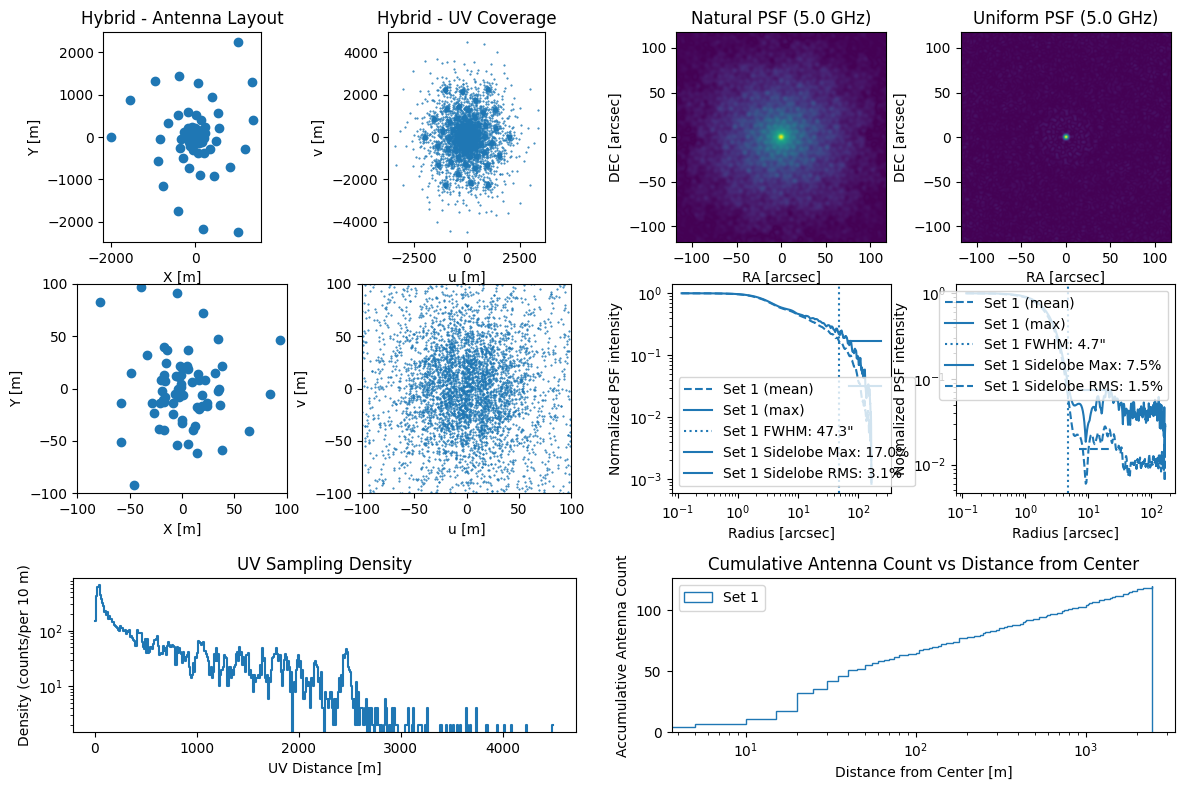

In [5]:
# Define hybrid parameters
reload(fss)
array_config = {"n_antennas": 120, "min_dist": 1.5, "n_core":48,
                                      "r_start": 35.0, "r_max": 2000., "n_turns": 1.5, "rotation_offset": 0., "sigma_g": 15.2,
                                      "latitude": 39.5846}


positions_hybrid = fss.generate_hybrid_rand_spiral_array(**array_config)

figname = (
    f"fig-fasr-a-hybrid-{len(positions_hybrid)}-"
    f"n_core={array_config['n_core']}-sigma_g={array_config['sigma_g']:.1f}-"
    f"n_turns={array_config['n_turns']:.1f}-"
    f"r_start={array_config['r_start']:.1f}-r_max={array_config['r_max']:.0f}.jpg")
print(f'fig saved to {figname}')
fss.plot_all_panels(positions_hybrid, "Hybrid", frequency=5, figname=figname, plot_psf_fit=False)

## Save the configuration for FASR-A hybrid configuration

In [6]:
config_file = f"fasr-a_random_spiral_hybrid_{len(positions_hybrid)}.cfg"
config_filename = config_file
if os.path.exists(config_file):
    print(f'Requested configuration file {config_file} already exists. Adding version number to it.')
    n = 0
    while n < 1000:
        config_filename = config_file.replace('.cfg', f'.00{n+1}.cfg')
        if os.path.exists(config_filename):
            n +=1
        else:
            break
print(f'writing configuration file {config_filename}')
fss.write_casa_antenna_list(config_filename, positions_hybrid, 
                            cofa_lon=dsa_longitude, cofa_lat=dsa_latitude, cofa_alt=dsa_altitude, diam=1.5)

Requested configuration file fasr-a_random_spiral_hybrid_120.cfg already exists. Adding version number to it.
writing configuration file fasr-a_random_spiral_hybrid_120.004.cfg
Wrote fasr-a_random_spiral_hybrid_120.004.cfg


## Compare the configuration with the previous 168-element 3-armed log spiral array

Set 1: Beam (Natural) FWHM Major: 37.50 arcsec, Minor: 37.23"
Set 1: Beam (Uniform) FWHM Major: 3.99 arcsec, Minor: 3.98"
Set 1: Sidelobe RMS (Natural): 1.6%
Set 1: Sidelobe RMS (Uniform): 0.9%
Set 2: Beam (Natural) FWHM Major: 47.62 arcsec, Minor: 47.04"
Set 2: Beam (Uniform) FWHM Major: 4.68 arcsec, Minor: 4.81"
Set 2: Sidelobe RMS (Natural): 3.3%
Set 2: Sidelobe RMS (Uniform): 1.5%
'plot_all_panels' completed at 2026-02-11 11:25:26; runtime: 1.42 seconds


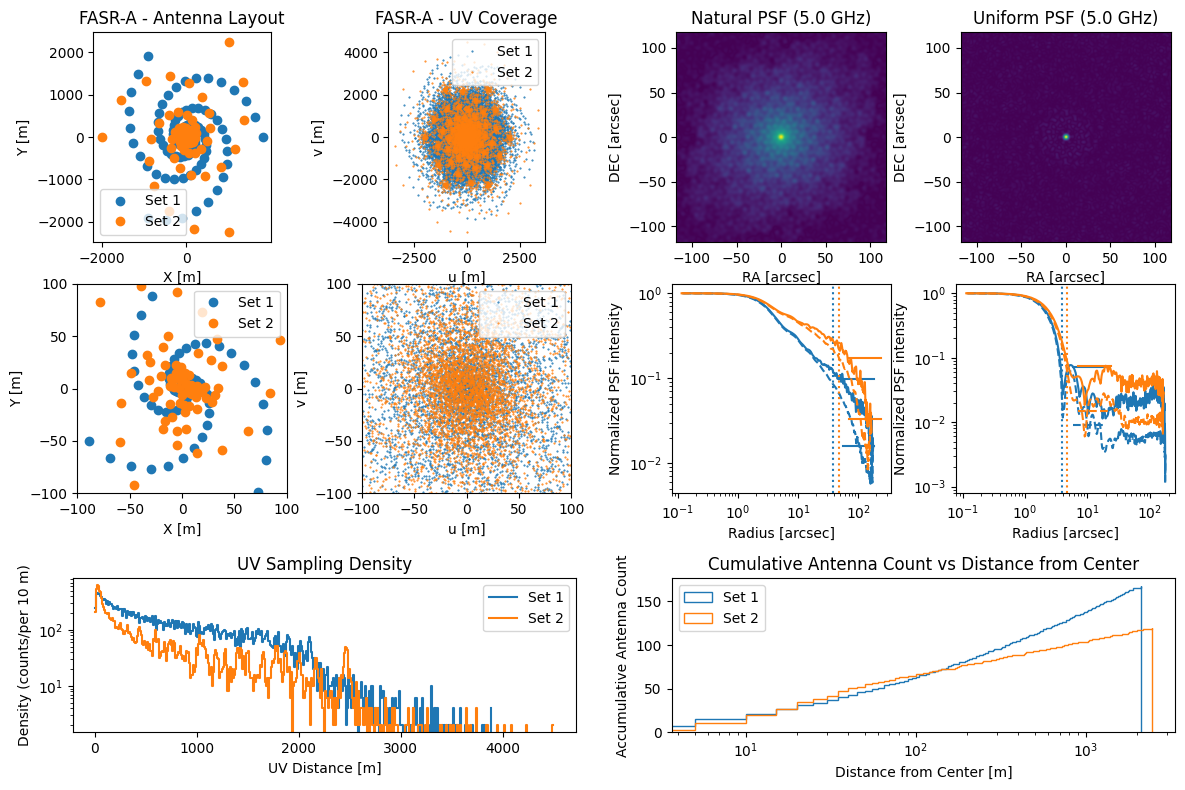

In [7]:
import importlib
importlib.reload(fss)
positions_sy, _ = fss.read_casa_antenna_list('fasr_Log_Spiral-168.cfg')
positions_hybrid, _ = fss.read_casa_antenna_list('fasr-a_random_spiral_hybrid_120.cfg')
fss.plot_all_panels([positions_sy, positions_hybrid], "FASR-A", plot_psf_fit=False, no_psf_legend=True)

In [8]:
positions_hybrid.shape

(120, 2)

## Add Remote Antennas (Random Annulus)
Starting from `fasr-a_random_spiral_hybrid_120.cfg`, add `n_remote` antennas randomly distributed in radius from the center of the array (default: 10 antennas in 3–10 km).

**Random seed (`random_seed`)**: controls the pseudo-random number generator used to place the remote antennas.
- Use a fixed integer (e.g. `0`) for *reproducible* antenna locations.
- Change the integer to generate a different random realization.
- Set to `None` to use a non-deterministic seed (results will change each run).

This writes a new CASA config, reads it back with `fss.read_casa_antenna_list`, and compares it against the base hybrid config.

Writing: fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg
Wrote fasr-a_random_spiral_hybrid_120_remote10_r2-10km.cfg
Max |ΔE|, |ΔN| for original antennas (m): [6.11775739e-07 7.36126728e-07]
Total antennas: 130
Remote antennas: 10
Set 1: Beam (Natural) FWHM Major: 13.87 arcsec, Minor: 14.78"
Set 1: Beam (Uniform) FWHM Major: 3.50 arcsec, Minor: 2.58"
Set 1: Sidelobe RMS (Natural): 4.0%
Set 1: Sidelobe RMS (Uniform): 1.4%
Set 2: Beam (Natural) FWHM Major: 47.62 arcsec, Minor: 47.04"
Set 2: Beam (Uniform) FWHM Major: 4.68 arcsec, Minor: 4.81"
Set 2: Sidelobe RMS (Natural): 3.3%
Set 2: Sidelobe RMS (Uniform): 1.5%
'plot_all_panels' completed at 2026-02-11 11:26:02; runtime: 1.48 seconds


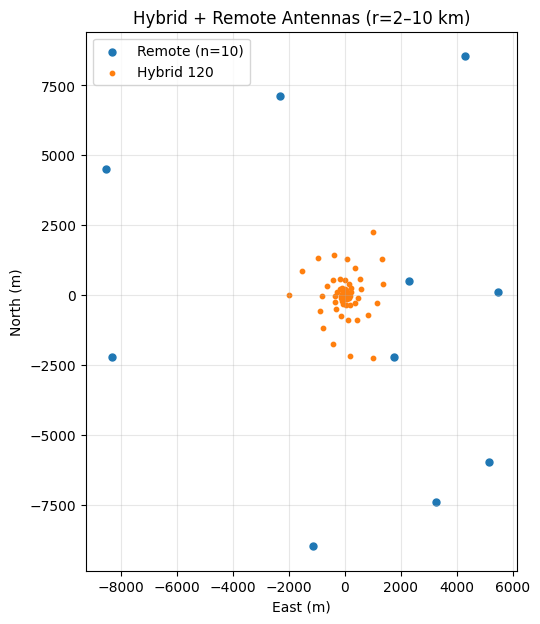

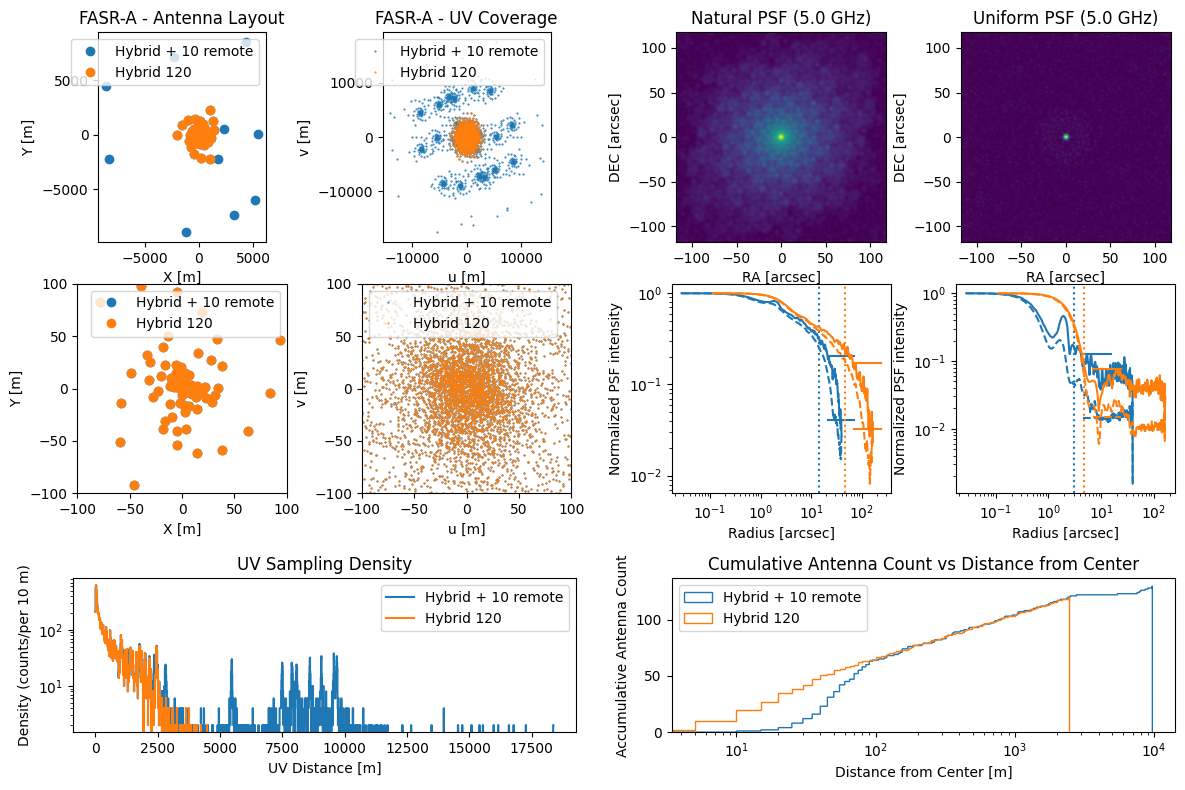

In [12]:
# --- Remote antenna parameters ---
base_cfg = 'fasr-a_random_spiral_hybrid_120.cfg'

n_remote = 10
r_min_km = 2.0
r_max_km = 10.0
random_seed = 0  # fixed int => reproducible; change for new realization; None => non-deterministic

# Read the base hybrid configuration (positions are local East/North offsets in meters)
positions_hybrid, (cofa_lon, cofa_lat, cofa_alt) = fss.read_casa_antenna_list(base_cfg)

rng = np.random.default_rng(random_seed)
r_min_m = r_min_km * 1e3
r_max_m = r_max_km * 1e3

# Sample uniformly in area over an annulus (r in [r_min, r_max])
u = rng.random(n_remote)
r = np.sqrt(u * (r_max_m**2 - r_min_m**2) + r_min_m**2)
theta = rng.uniform(0.0, 2.0 * np.pi, size=n_remote)
remote_offsets = np.column_stack([r * np.cos(theta), r * np.sin(theta)])

array_center = positions_hybrid.mean(axis=0)
positions_remote = array_center + remote_offsets
positions_hybrid_remote_generated = np.vstack([positions_hybrid, positions_remote])

# Write new configuration file (avoid overwriting)
new_cfg_base = (
    f'fasr-a_random_spiral_hybrid_{len(positions_hybrid)}_'
    f'remote{n_remote}_r{r_min_km:.0f}-{r_max_km:.0f}km.cfg'
)
new_cfg = new_cfg_base
if os.path.exists(new_cfg):
    n = 1
    while True:
        candidate = new_cfg_base.replace('.cfg', f'.{n:03d}.cfg')
        if not os.path.exists(candidate):
            new_cfg = candidate
            break
        n += 1

print(f'Writing: {new_cfg}')
fss.write_casa_antenna_list(
    new_cfg,
    positions_hybrid_remote_generated,
    cofa_lon=cofa_lon,
    cofa_lat=cofa_lat,
    cofa_alt=cofa_alt,
    diam=1.5,
)

# Read back and compare to base hybrid
positions_hybrid_remote, _ = fss.read_casa_antenna_list(new_cfg)

diff = positions_hybrid_remote[: len(positions_hybrid)] - positions_hybrid
print('Max |ΔE|, |ΔN| for original antennas (m):', np.nanmax(np.abs(diff), axis=0))
print('Total antennas:', positions_hybrid_remote.shape[0])
print('Remote antennas:', positions_hybrid_remote.shape[0] - positions_hybrid.shape[0])

# Quick overlay plot
plt.figure(figsize=(7, 7))
plt.scatter(positions_remote[:, 0], positions_remote[:, 1], s=25, label=f'Remote (n={n_remote})')
plt.scatter(positions_hybrid[:, 0], positions_hybrid[:, 1], s=10, label='Hybrid 120')
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('East (m)')
plt.ylabel('North (m)')
plt.title(f'Hybrid + Remote Antennas (r={r_min_km:.0f}–{r_max_km:.0f} km)')
plt.grid(True, alpha=0.3)
plt.legend()

# Full panel comparison (layout/uv/psf/density)
fss.plot_all_panels(
    [positions_hybrid_remote, positions_hybrid],
    title='FASR-A',
    labels=[f'Hybrid + {n_remote} remote', 'Hybrid 120'],
    plot_psf_fit=False,
    no_psf_legend=True,
)


## Check shadowing

In [10]:
importlib.reload(fss)
dish_size = 1.5
latitude = dsa_latitude
ha, dec, el_map, shadow_map = fss.calculate_shadowing(positions_hybrid, dish_size, latitude)

Simulating shadowing for 120 antennas...


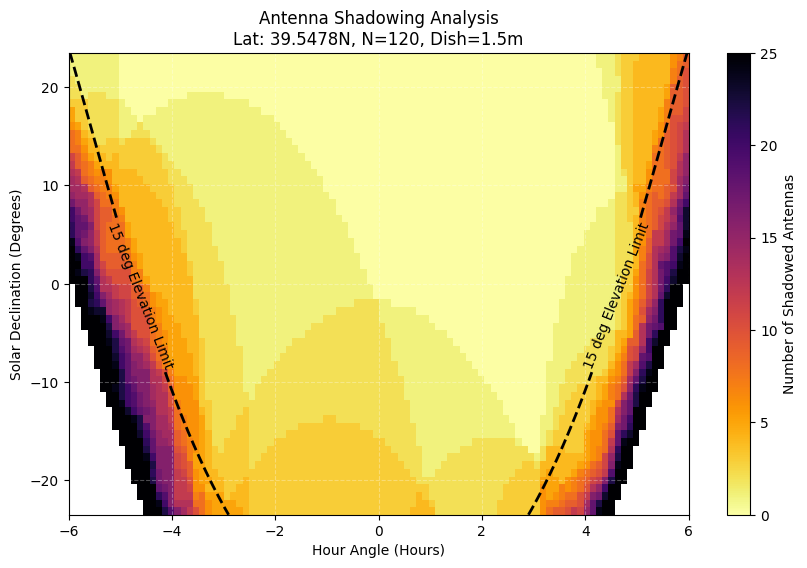

In [11]:
# 3. Plotting
plt.figure(figsize=(10, 6))
# Convert HA to hours for plotting
ha_hours = ha / 15.0

im = plt.imshow(shadow_map, aspect='auto', origin='lower',
           extent=[ha_hours.min(), ha_hours.max(), dec.min(), dec.max()],
           cmap='inferno_r', vmin=0, vmax=25)

# B. Add the "Operational Window" Contour (El = 15 deg)
# We need to meshgrid the X/Y coordinates for contour plotting
X, Y = np.meshgrid(ha_hours, dec)
CS = plt.contour(X, Y, el_map, levels=[15.0], colors='k', linewidths=2, linestyles='--')
plt.clabel(CS, inline=1, fontsize=10, fmt='%1.0f deg Elevation Limit')

# C. "Grey out" the non-operational area (El < 15 deg)
# We create a masked array where El >= 15 is transparent, and El < 15 is grey
# contourf can do this easily
plt.contourf(X, Y, el_map, levels=[-90, 15], colors='gray', alpha=0.0)

cbar = plt.colorbar(im, label='Number of Shadowed Antennas')
plt.xlabel('Hour Angle (Hours)')
plt.ylabel('Solar Declination (Degrees)')
plt.title(f'Antenna Shadowing Analysis\nLat: {latitude}N, N={len(positions_hybrid)}, Dish={dish_size}m')
plt.grid(color='white', alpha=0.3, linestyle='--')


plt.show()